# From Ensembles to Neural Networks — Diabetes Prediction


**Key shift from trees:** NNs learn via gradient descent. Gradients are proportional to feature magnitude, so without standardisation a single large-valued feature (e.g. `blood_glucose_level`) dominates every weight update. 

**Always standardise inputs.**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import keras
import pandas as pd
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import seaborn as sns

DATA_PATH = "/app/datasets"
CKPT_PATH = "/app/checkpoints"
SAVE_FORMAT = "h5"
GLOBAL_SEED = 42

tf.keras.utils.set_random_seed(GLOBAL_SEED)
tf.config.experimental.enable_op_determinism()

os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(CKPT_PATH, exist_ok=True)


2026-05-08 07:53:57.968764: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 07:53:57.968821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 07:53:57.970973: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Utility Functions

In [ ]:
def generate_plot(result):
    """Plot training and validation curves with smoothing overlay."""
    metrics = ["loss", "accuracy", "precision", "recall"]
    titles  = ["Loss", "Accuracy", "Precision", "Recall"]

    plt.figure(figsize=(14, 10))
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        plt.subplot(2, 2, idx + 1)

        train_vals = result.history[metric]
        val_vals   = result.history[f'val_{metric}']
        plt.plot(train_vals, color='blue',   label=f'Train {title}')
        plt.plot(val_vals,   color='orange', label=f'Val {title}')

        plt.xlabel('Epoch')
        plt.ylabel(title)
        plt.title(f'{title} Over Time')
        plt.legend()

    plt.tight_layout()
    plt.show()


## Load, Preprocess & Split

Steps: encode categoricals → stratified 70/15/15 split → **StandardScaler** (fit on train only, transform all three splits).

Fitting the scaler only on train data prevents **data leakage** — the model never sees val/test statistics during training.

In [3]:
CSV_FILE = "diabetes_prediction_dataset.csv"
csv_path = os.path.join(DATA_PATH, CSV_FILE)

df = pd.read_csv(csv_path)
df.drop_duplicates(inplace=True)
df = df[df['gender'] != 'Other']

from sklearn.preprocessing import LabelEncoder
from pandas.core.dtypes.common import is_numeric_dtype

encoders = {}
for column in df.columns:
    if not is_numeric_dtype(df[column]):
        label = LabelEncoder()
        df[column] = label.fit_transform(df[column])
        encoders[column] = label

print(df.shape)
df.head()



(96128, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [4]:
df.describe()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000
mean,0.415769,41.796617,0.077615,0.040810,2.231015,27.321450,5.532633,138.218001,0.088237
std,0.492857,22.463329,0.267567,0.197851,1.879861,6.767811,1.073225,40.911190,0.283640
min,0.000000,0.080000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,0.000000,43.000000,0.000000,0.000000,3.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,59.000000,0.000000,0.000000,4.000000,29.860000,6.200000,159.000000,0.000000
max,1.000000,80.000000,1.000000,1.000000,5.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
X = df.drop('diabetes', axis=1).values
Y = df['diabetes'].values

# 70% train | 15% val | 15% test  (stratified at every step)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.20, stratify=Y, random_state=GLOBAL_SEED
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, stratify=Y_temp, random_state=GLOBAL_SEED
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train pos rate: {Y_train.mean():.3f} | Val pos rate: {Y_val.mean():.3f}")


Train: (76902, 8), Val: (9613, 8), Test: (9613, 8)
Train pos rate: 0.088 | Val pos rate: 0.088


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Features: {X_train.shape[1]}")
print(f"Sample (scaled): {X_train[0].round(3)}")

Features: 8
Sample (scaled): [-0.842 -0.88  -0.29  -0.206  0.94  -0.47   0.528 -0.935]


In [7]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", {k: round(v, 3) for k, v in class_weights.items()})

Class weights: {0: 0.548, 1: 5.666}


In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
], name="diabetes_classifier")

model.summary()

Model: "diabetes_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 833 (3.25 KB)
Trainable params: 833 (3.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    # optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        f'{CKPT_PATH}/diabetes_classifier_improved.{SAVE_FORMAT}',
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    # ReduceLROnPlateau(
    #     monitor='val_loss',
    #     factor=0.5,
    #     patience=5,
    #     min_lr=1e-6,
    #     verbose=1
    # ),
]


In [11]:
result = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=512,
    validation_data=(X_val, Y_val),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1778226846.603307 1888145 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/151 [============================>.] - ETA: 0s - loss: 0.6584 - accuracy: 0.8209 - auc: 0.6641 - precision: 0.2261 - recall: 0.4248
Epoch 1: val_loss improved from inf to 0.50862, saving model to /app/checkpoints/diabetes_classifier_improved.h5
151/151 [==============================] - 6s 13ms/step - loss: 0.6555 - accuracy: 0.8207 - auc: 0.6700 - precision: 0.2279 - recall: 0.4321 - val_loss: 0.5086 - val_accuracy: 0.8036 - val_auc: 0.8815 - val_precision: 0.2785 - val_recall: 0.7712 - lr: 3.0000e-04
Epoch 2/50
 14/151 [=>............................] - ETA: 1s - loss: 0.5134 - accuracy: 0.8115 - auc: 0.8906 - precision: 0.2995 - recall: 0.8102

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


149/151 [============================>.] - ETA: 0s - loss: 0.4264 - accuracy: 0.8247 - auc: 0.9217 - precision: 0.3179 - recall: 0.8625
Epoch 2: val_loss improved from 0.50862 to 0.35932, saving model to /app/checkpoints/diabetes_classifier_improved.h5
151/151 [==============================] - 1s 10ms/step - loss: 0.4260 - accuracy: 0.8248 - auc: 0.9219 - precision: 0.3182 - recall: 0.8630 - val_loss: 0.3593 - val_accuracy: 0.8438 - val_auc: 0.9410 - val_precision: 0.3489 - val_recall: 0.8903 - lr: 3.0000e-04
Epoch 3/50
147/151 [============================>.] - ETA: 0s - loss: 0.3159 - accuracy: 0.8526 - auc: 0.9498 - precision: 0.3641 - recall: 0.8968
Epoch 3: val_loss improved from 0.35932 to 0.29533, saving model to /app/checkpoints/diabetes_classifier_improved.h5
151/151 [==============================] - 2s 10ms/step - loss: 0.3155 - accuracy: 0.8528 - auc: 0.9497 - precision: 0.3643 - recall: 0.8966 - val_loss: 0.2953 - val_accuracy: 0.8605 - val_auc: 0.9543 - val_precision: 0.

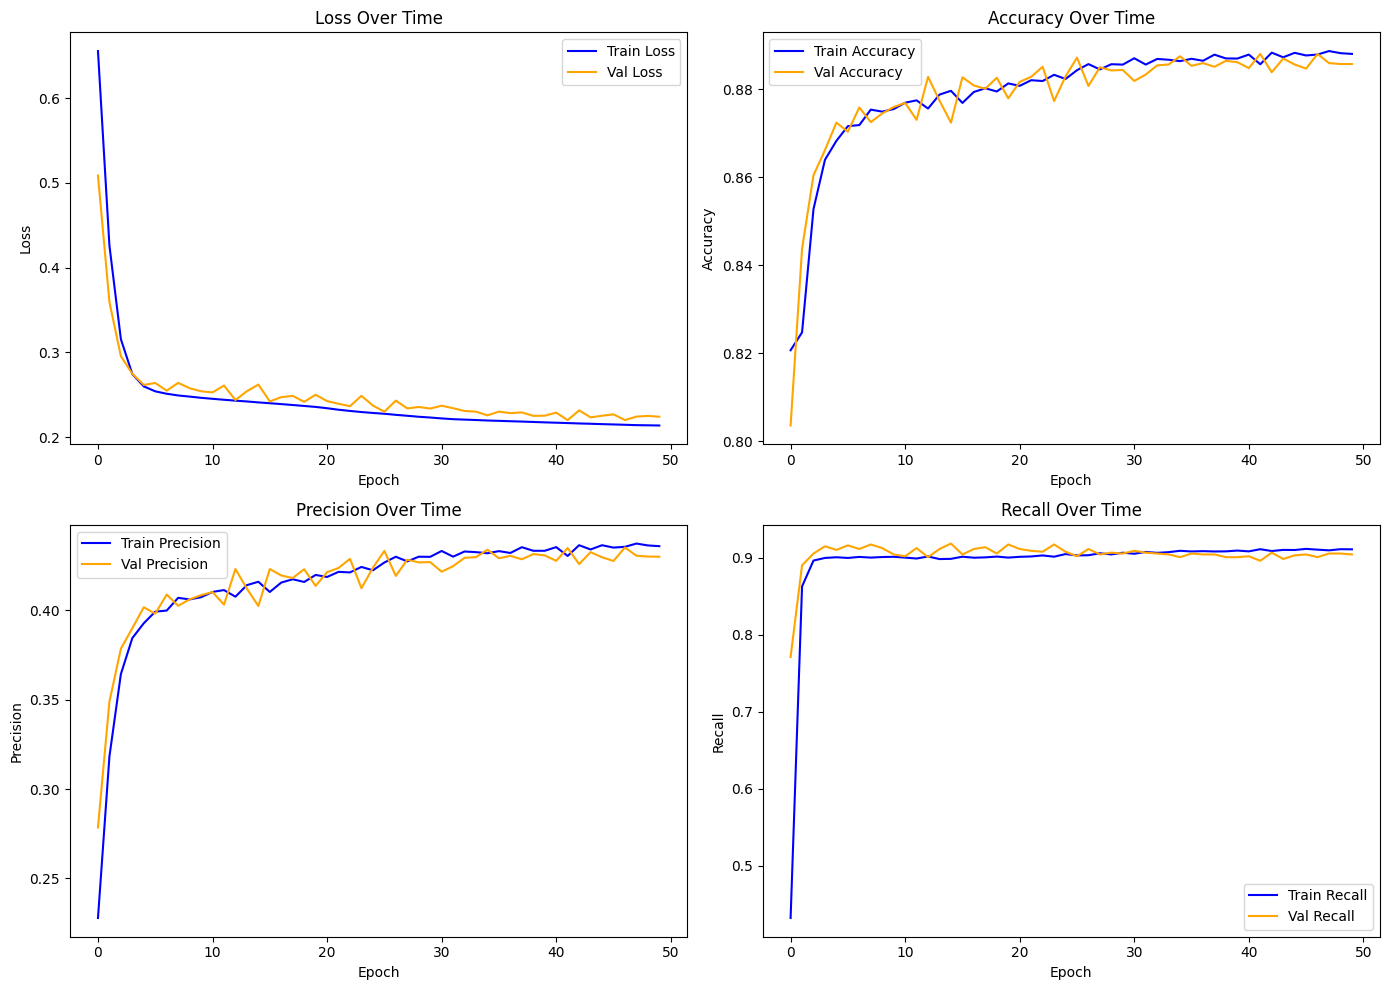

In [12]:
generate_plot(result)


## Threshold Tuning & Evaluation


In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import numpy as np

y_prob = model.predict(X_val).flatten()
precision_curve, recall_curve, thresholds = precision_recall_curve(Y_val, y_prob)

# F1 score
f1 = 2 * (precision_curve * recall_curve) / (
    precision_curve + recall_curve + 1e-8
)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best threshold (F1={f1[best_idx]:.4f}): {best_threshold:.4f}")

301/301 [==============================] - 1s 2ms/step
Best threshold (F2=0.7603): 0.7542


301/301 [==============================] - 1s 2ms/step

=== Test Set Report ===
              precision    recall  f1-score   support

     Healthy       0.98      0.96      0.97      8765
    Diabetic       0.64      0.75      0.69       848

    accuracy                           0.94      9613
   macro avg       0.81      0.86      0.83      9613
weighted avg       0.95      0.94      0.94      9613



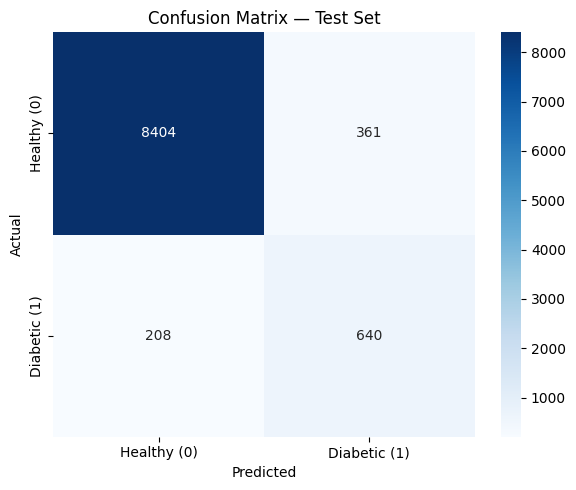

In [14]:
y_prob_test = model.predict(X_test).flatten()
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print("\n=== Test Set Report ===")
print(classification_report(Y_test, y_pred_test, target_names=['Healthy', 'Diabetic']))

cm = confusion_matrix(Y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Diabetic (1)'],
            yticklabels=['Healthy (0)', 'Diabetic (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()